In [ ]:
import serial
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from scipy.fft import rfft
from sklearn.preprocessing import StandardScaler,normalize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
load_dotenv()  

In [ ]:
with serial.Serial(os.getenv('port'), 115200, timeout=2) as ser:
    ser.reset_input_buffer()
    data_chunks = []

    for i in range(120):
        # 1. Hunt for the 0xAA 0x55 sync marker to align the frame
        while True:
            if ser.read(1) == b'\xAA':
                if ser.read(1) == b'\x55':
                    break
        
        # 2. Extract exactly the 6000 byte payload
        raw = ser.read(6000)
        if len(raw) < 6000:
            print("Warning: Incomplete packet received, skipping...")
            continue
            
        parsed = np.frombuffer(raw, dtype='>i2')
        reshaped = parsed.reshape(-1, 3)
        print(reshaped)
        data_chunks.append(reshaped)

            
final_matrix = np.vstack(data_chunks)
df = pd.DataFrame(final_matrix, columns=['Accel_X', 'Accel_Y', 'Accel_Z'])
df = df / 16384.0

# df.to_csv(//your path//, index=False)  # Uncomment and specify your path to save the DataFrame
print(df.head(15))
print(f"Total shape: {df.shape}")

CONVERTING EACH CLASS INTO ITS OWN DATASET

In [2]:
main_path = os.getenv('main_path')
window_size = 128
cols = ['Variance_X', 'Variance_Y', 'Variance_Z', 'RMS_X', 'RMS_Y', 'RMS_Z', 'PtP_X', 'Ptp_Y', 'Ptp_Z', 'FFT_X', 'FFT_Y', 'FFT_Z']

In [ ]:
for classes in os.listdir(main_path):
    final_df = pd.DataFrame(columns=cols)
    features_list = []
    for filename in os.listdir(os.path.join(main_path,classes)):
        if not filename.endswith('.csv') or filename.startswith('final_'):
            continue
        curr_df = pd.read_csv(os.path.join(main_path,classes,filename))
        for i in range(0,len(curr_df),window_size):
            if(i+window_size > len(curr_df)):
                break
            window = curr_df.iloc[i:i+window_size].values
            mean = window.mean(axis=0)
            window = window - mean
            variance = np.var(window, axis=0)
            rms = np.sqrt(np.mean(window**2, axis=0))
            ptp = np.ptp(window, axis=0)
            fft = np.sum(np.abs(rfft(window, axis=0))**2, axis=0) / len(window)
            features = np.concatenate([variance, rms, ptp, fft],axis=0).reshape(1,-1) 
            features_list.append(features)

    final_df = pd.DataFrame(np.vstack(features_list), columns=cols)
    final_df['Label'] = classes
    final_df.to_csv(os.path.join(main_path,classes,'_'.join(["final",classes,"dataset.csv"])),index=False)

VISUALISING EACH CLASS DIFFERENCES

Visualizing feature distributions for class: Bearing_Fault


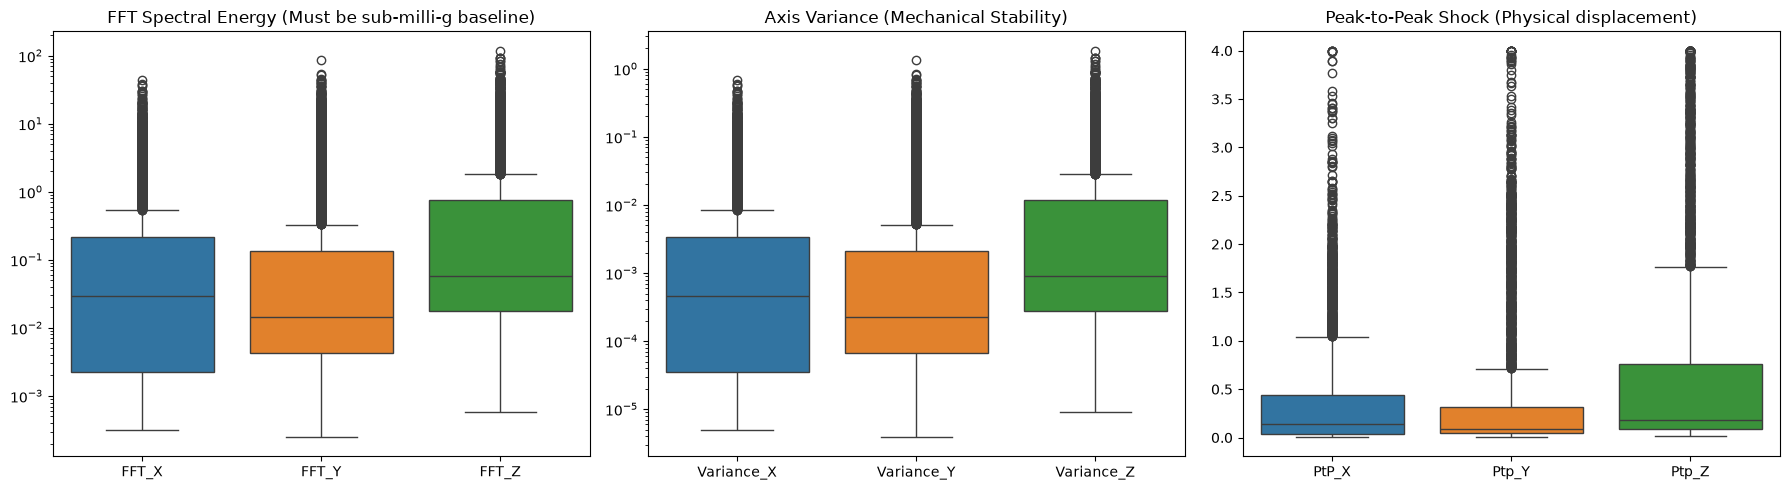

             FFT_X        FFT_Y        FFT_Z
count  4669.000000  4669.000000  4669.000000
mean      0.832954     1.401890     2.324172
std       2.790083     4.695798     7.446119
min       0.000313     0.000252     0.000591
25%       0.002220     0.004290     0.018002
50%       0.029584     0.014267     0.057906
75%       0.219157     0.135072     0.746018
max      44.332981    85.674533   118.561470
Visualizing feature distributions for class: Healthy


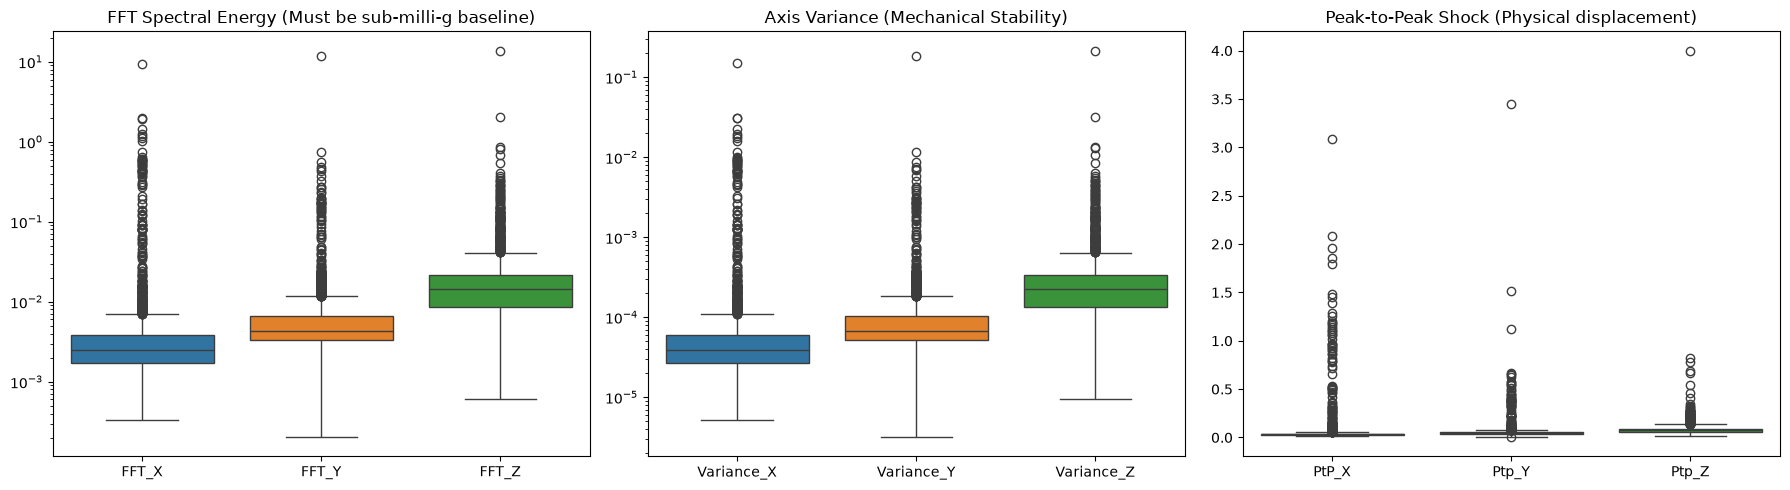

             FFT_X        FFT_Y        FFT_Z
count  4677.000000  4677.000000  4677.000000
mean      0.010848     0.010402     0.022496
std       0.155020     0.172286     0.205978
min       0.000331     0.000206     0.000600
25%       0.001711     0.003339     0.008686
50%       0.002489     0.004354     0.014563
75%       0.003844     0.006677     0.021668
max       9.510944    11.676146    13.786971
Visualizing feature distributions for class: Imbalance


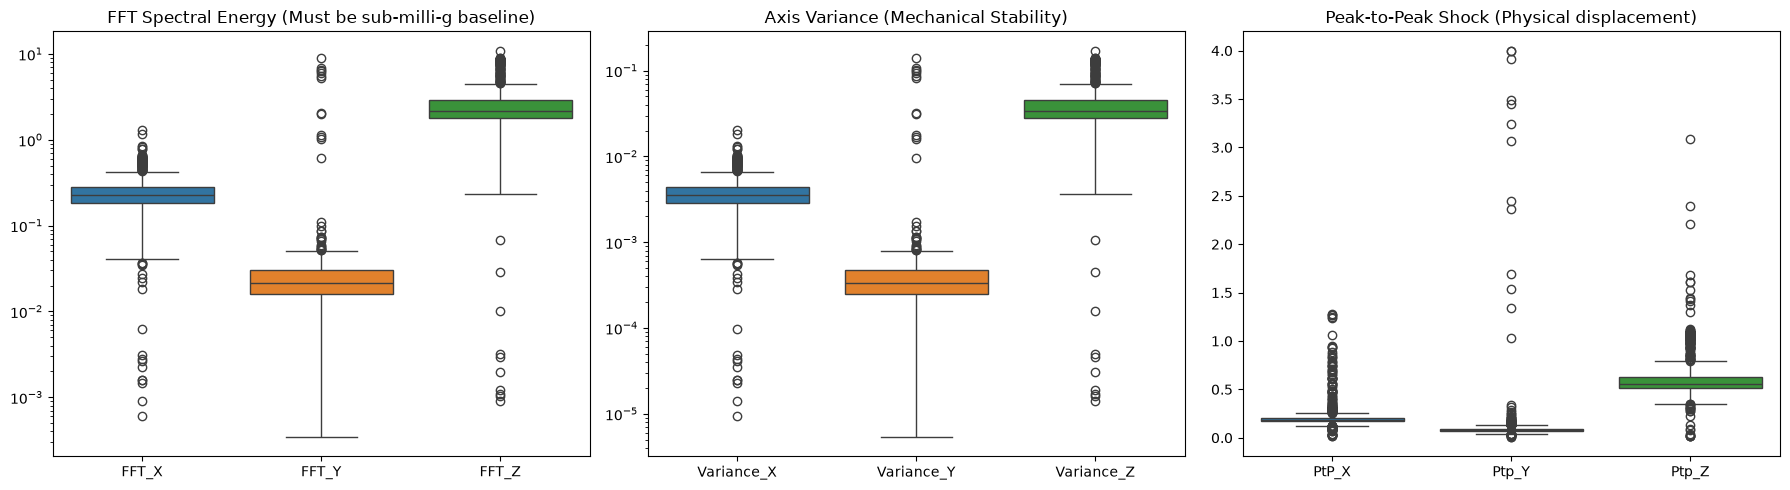

             FFT_X        FFT_Y        FFT_Z
count  4685.000000  4685.000000  4685.000000
mean      0.235473     0.034600     2.402298
std       0.081215     0.259337     1.065503
min       0.000601     0.000347     0.000904
25%       0.184870     0.015957     1.816133
50%       0.227636     0.021712     2.177921
75%       0.281869     0.030302     2.910909
max       1.287157     9.026384    10.952422
Visualizing feature distributions for class: Transient_Shock


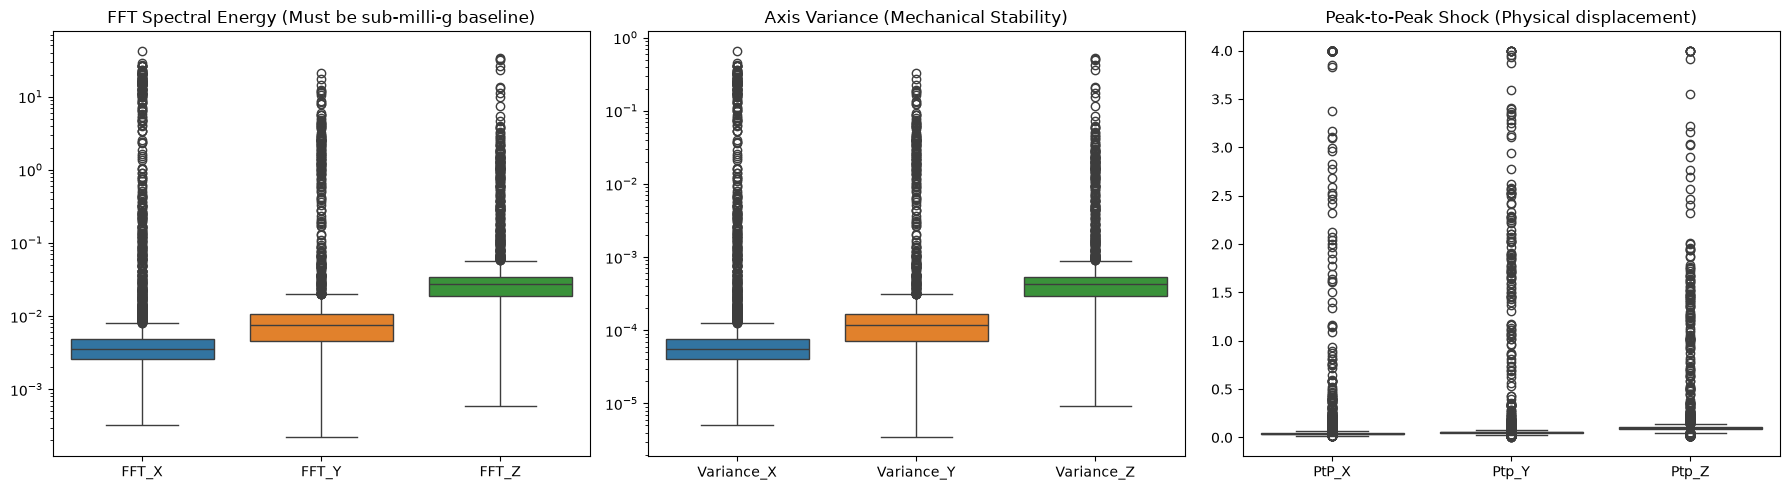

             FFT_X        FFT_Y        FFT_Z
count  4637.000000  4637.000000  4637.000000
mean      0.340301     0.083280     0.102993
std       2.375712     0.730231     1.068756
min       0.000329     0.000225     0.000594
25%       0.002622     0.004544     0.019072
50%       0.003520     0.007493     0.027641
75%       0.004842     0.010691     0.034419
max      42.478155    21.041959    33.588394


In [139]:
for classes in os.listdir(main_path):
    for filename in os.listdir(os.path.join(main_path,classes)):
        if not filename.startswith("final_"):
            continue
        df = pd.read_csv(os.path.join(main_path,classes,filename))

        # 2. Set up a visualization grid
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        print(f"Visualizing feature distributions for class: {classes}")
        # title = str.join(classes,"Baseline Verification: Feature Distributions")
        # fig.suptitle(title, fontsize=16)

        # 3. FFT Spectral Energy Check
        sns.boxplot(data=df[['FFT_X', 'FFT_Y', 'FFT_Z']], ax=axes[0])
        axes[0].set_title('FFT Spectral Energy (Must be sub-milli-g baseline)')
        axes[0].set_yscale('log') # Log scale reveals the baseline vs transient spikes

# 4. Variance Check
        sns.boxplot(data=df[['Variance_X', 'Variance_Y', 'Variance_Z']], ax=axes[1])
        axes[1].set_title('Axis Variance (Mechanical Stability)')
        axes[1].set_yscale('log')

# 5. Peak-to-Peak (PtP) Check
        sns.boxplot(data=df[['PtP_X', 'Ptp_Y', 'Ptp_Z']], ax=axes[2])
        axes[2].set_title('Peak-to-Peak Shock (Physical displacement)')

        plt.tight_layout()
        plt.show()

# 6. Statistical hard-check
        print(df[['FFT_X', 'FFT_Y', 'FFT_Z']].describe())

MASTER DATASET 

In [ ]:
master_data = pd.DataFrame(columns=cols)
for classes in os.listdir(main_path):
    for filename in os.listdir(os.path.join(main_path,classes)):
        if not filename.startswith("final_"):
            continue
        df = pd.read_csv(os.path.join(main_path,classes,filename))
        master_data = pd.concat([master_data, df], ignore_index=True)
master_data.to_csv(os.path.join(main_path,'master_dataset.csv'),index=False)
master_data.shape
master_data[['Label']].value_counts()

In [ ]:
master_data = pd.read_csv(os.path.join(main_path,'master_dataset.csv'))
labels = master_data['Label'].unique()
X = master_data.loc[:,"Variance_X":"FFT_Z"]
y = master_data["Label"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
scaler = StandardScaler(with_mean=True, with_std=True)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train,y_train)
predictions = classifier.predict(X_test)

matrix = confusion_matrix(y_test,predictions,labels=labels)

In [13]:
print(labels)
confusion_matrix(y_test,predictions,labels=labels)

<StringArray>
['Bearing_Fault', 'Healthy', 'Imbalance', 'Transient_Shock']
Length: 4, dtype: str


array([[1159,  178,    0,   64],
       [ 132, 1107,    1,  163],
       [   6,    2, 1396,    2],
       [ 108,  257,    3, 1023]])